# 02 · Pipeline comparison

Run **different restoration pipelines on the same input, with the same degradation, scored by the same metrics**, and compare them. This drives the repo-root [`orchestrator.py`](../orchestrator.py) under the hood (via `nb.run_pipeline`), so every run is fair and reproducible.

The four endpoints:

| step | what it does | resolution |
|---|---|---|
| `joint` | denoise **and** super-resolve in one model | LR→HR |
| `sr` | spatial super-resolution | LR→HR |
| `denoise` | Noise2Noise U-Net denoiser | preserves res |
| `interp` | **temporal interpolation (my part)** | changes T |

Pipelines we compare here: **`joint`** vs the **`denoise → sr` cascade** (the thesis comparison), an **`sr`-only** baseline, and **`interp`**.

> Each `run_pipeline` call shells out to the orchestrator (can take minutes per run on GPU). Use `truncate=` to keep demo runs fast.

In [1]:
%load_ext autoreload
%autoreload 2
import nb_utils as nb

cfg = nb.Config(data_dir="/srv/fMRI-data", bold_file=None)
bold = cfg.resolve_bold()
RUNS = cfg.out_dir / "pipeline_runs"
TRUNC = 20    # frames per run for a quick demo; set 0 for the whole run
print("input:", bold.name)
print("runs ->", RUNS)

input: sub-01_ses-03_task-HcpLanguage_dir-ap_bold.nii.gz
runs -> /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs


## Run the pipelines

Architecture A (`degrade_once=yes`): the input is degraded **once** and fed to each pipeline, so `joint` and `denoise→sr` see the *same* noisy low-res input — apples to apples.

In [2]:
results = []

results.append(nb.run_pipeline(["joint"],            bold, RUNS / "joint",   truncate=TRUNC, seed=0))
results.append(nb.run_pipeline(["denoise", "sr"],  bold, RUNS / "cascade", truncate=TRUNC, seed=0))
results.append(nb.run_pipeline(["sr"],              bold, RUNS / "sr_only", truncate=TRUNC, seed=0))

for r in results:
    print(f"  {r['label']:<14} rc={r['returncode']}  metrics={'ok' if r['metrics'] else 'MISSING'}")

$ /srv/venvs/team4dbrain/team4dbrain/bin/python /home/özkan/fMRI_MedImg/orchestrator.py -i /srv/fMRI-data/sub-01_ses-03_task-HcpLanguage_dir-ap_bold.nii.gz -o /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/joint --degrade-once yes --noise auto --seed 0 --sr-model rcan3d --interp-mode fill-gaps --truncate 20 --steps joint
[orch] truncating to 20 frames from start=170 (seed=0)
[orch] degrade-once: spatial=True noise=True
[orch] degrade 20/20
[orch] step 'joint'  (cwd=/home/özkan/fMRI_MedImg)
[orch] slides -> /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/joint/slides (3 montages)

[orch] DONE -> /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/joint
[orch] metrics: {'reference_timepoints': 20, 'output_timepoints': 20, 'tsnr_reference': 21.213936428178375, 'tsnr_output': 27.819948641745295, 'tsnr_ratio': 1.3113996422084204, 'psnr_db': 21.943101596832275, 'ssim': 0.6477563679218292, 'final_output': 'final.nii.gz', 'final_produced_by': 'step0'}
$ /srv/venvs/team4dbr

## Comparison table

`psnr_db` / `ssim` are vs the clean reference (only defined when the time axis is unchanged); `tsnr_ratio` = output tSNR / reference tSNR (temporal signal stability — higher is smoother, which a denoiser should improve).

In [3]:
df = nb.metrics_table(results)
df

,ok,psnr_db,ssim,tsnr_output,tsnr_reference,tsnr_ratio,output_timepoints,reference_timepoints
pipeline,,,,,,,,
joint,True,21.943102,0.647756,27.819949,21.213936,1.311400,20,20
denoise+sr,True,3.608519,0.026361,0.887327,21.213936,0.041828,20,20
sr,True,26.981923,0.841536,51.023511,21.213936,2.405188,20,20


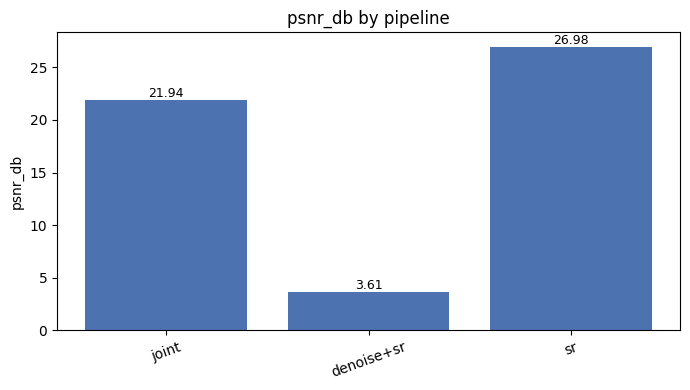

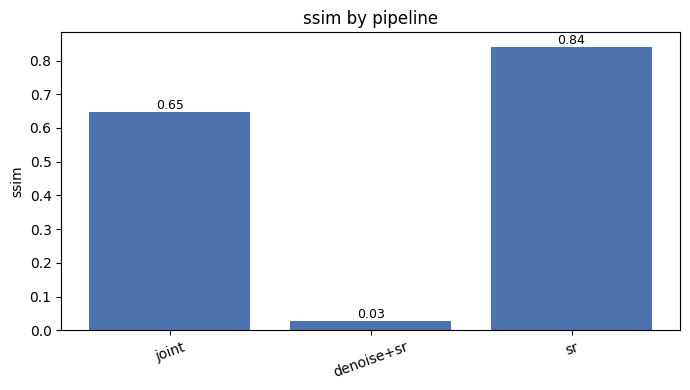

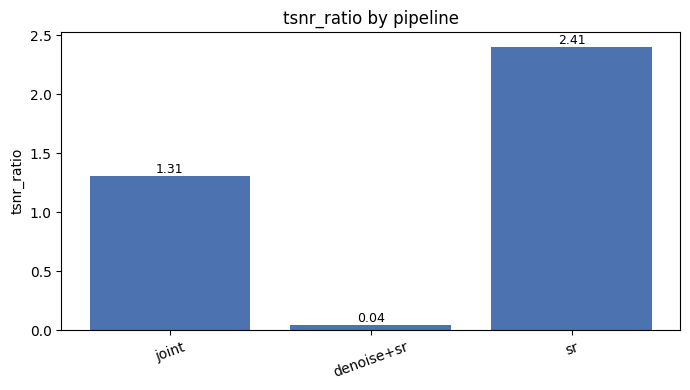

In [4]:
nb.bar_compare(df, "psnr_db", save_path=cfg.out_dir / "cmp_psnr.png")
nb.bar_compare(df, "ssim",    save_path=cfg.out_dir / "cmp_ssim.png")
nb.bar_compare(df, "tsnr_ratio", save_path=cfg.out_dir / "cmp_tsnr.png");

## Visual: degraded input vs pipeline output vs reference

The orchestrator writes montage slides for each run (`<run>/slides/*.png`). Here are the `joint` model's.

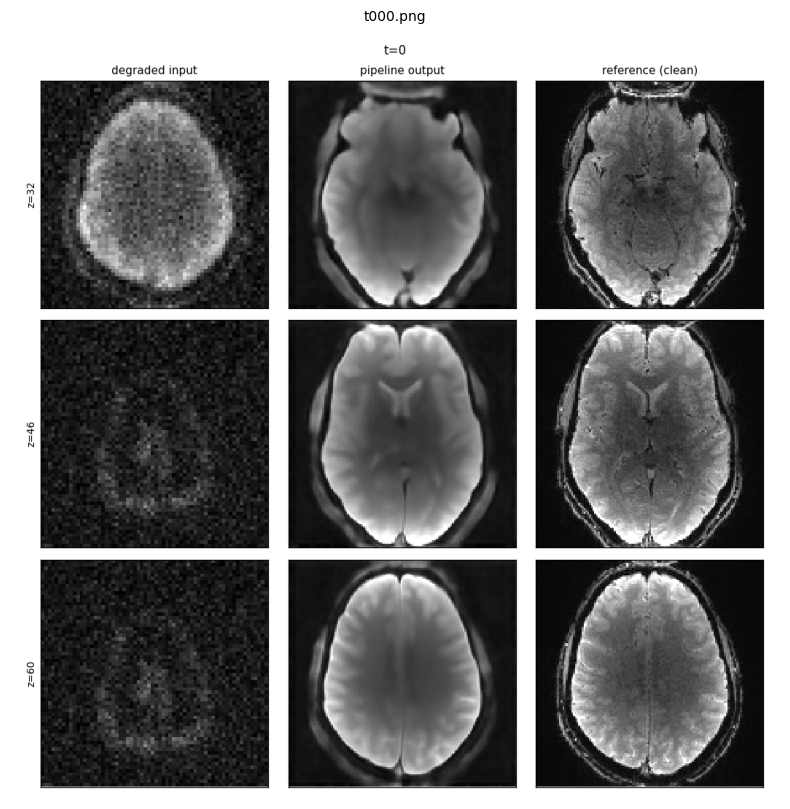

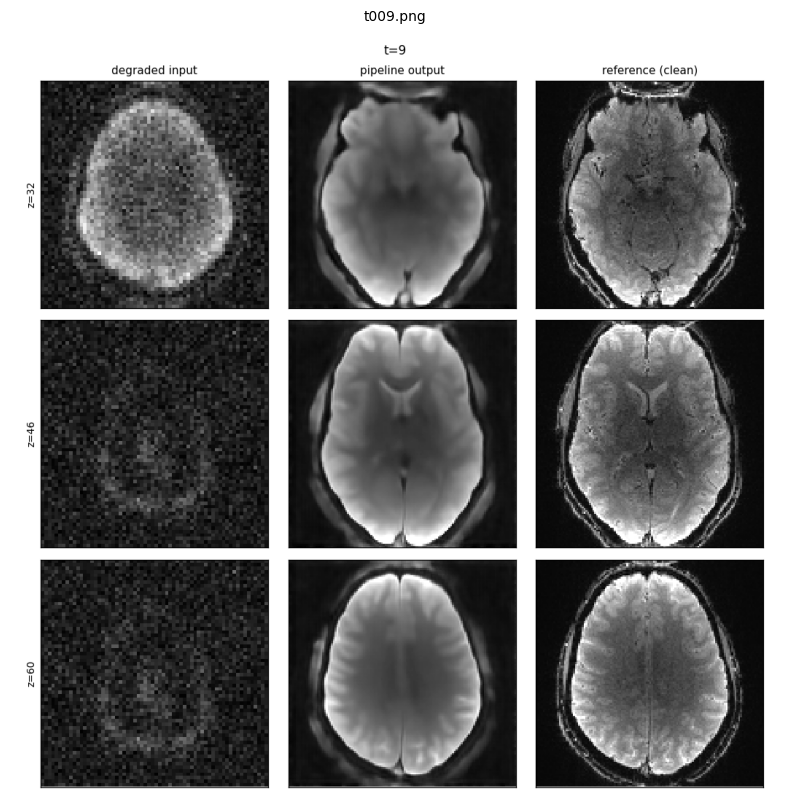

In [5]:
nb.show_slides(RUNS / "joint", max_n=2)

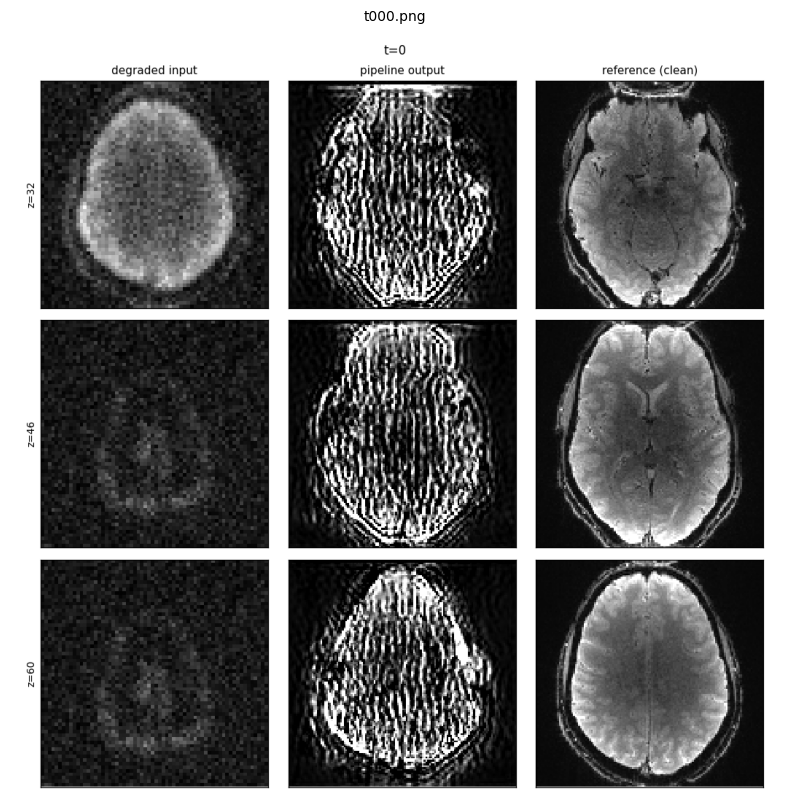

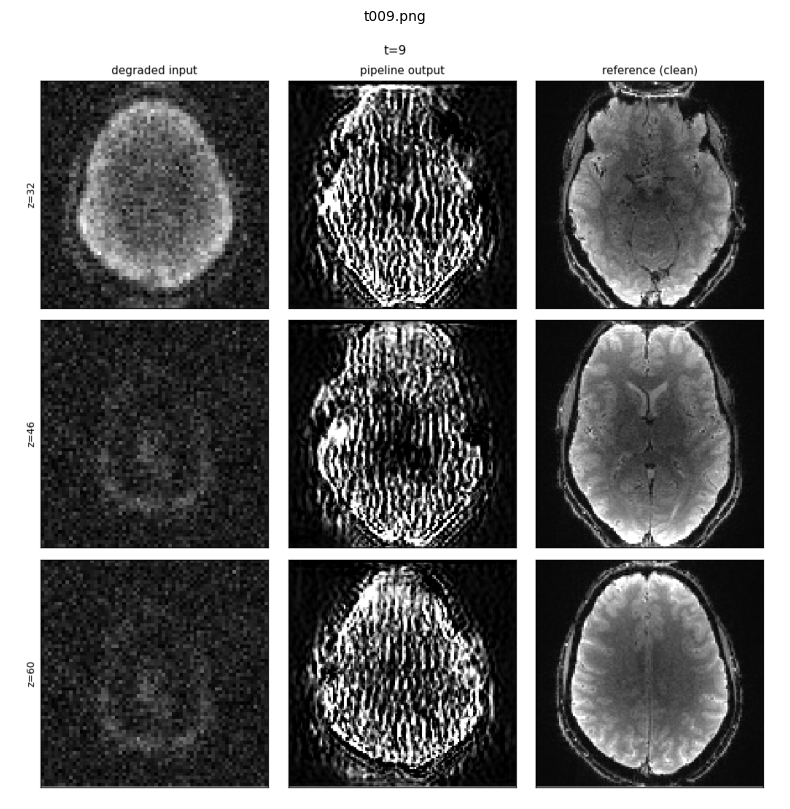

In [6]:
nb.show_slides(RUNS / "cascade", max_n=2)

## My part in a pipeline — temporal interpolation

`interp` changes the number of frames, so per-frame PSNR/SSIM vs the original is undefined (synthetic frames have no aligned ground truth). The orchestrator instead reports a **leave-out** PSNR/L1 (predict each held-out interior frame from its neighbours) under `interp_leaveout`, plus tSNR.

In [7]:
interp_res = nb.run_pipeline(["interp"], bold, RUNS / "interp",
                             truncate=TRUNC, seed=0, interp_mode="fill-gaps")
m = interp_res["metrics"] or {}
print("output timepoints:", m.get("output_timepoints"),
      "(reference:", m.get("reference_timepoints"), ")")
print("tsnr_ratio:", m.get("tsnr_ratio"))
m.get("interp_leaveout", "(no leave-out reported)")

$ /srv/venvs/team4dbrain/team4dbrain/bin/python /home/özkan/fMRI_MedImg/orchestrator.py -i /srv/fMRI-data/sub-01_ses-03_task-HcpLanguage_dir-ap_bold.nii.gz -o /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/interp --degrade-once yes --noise auto --seed 0 --sr-model rcan3d --interp-mode fill-gaps --truncate 20 --steps interp
[orch] norm_ref=25707.07 (manifest:sub-01_ses-03_task-HcpLanguage_dir-ap) | mask_fraction=0.339
[orch] truncating to 20 frames from start=170 (seed=0)
[orch] degrade-once: spatial=False noise=False
[orch] step 'interp'  (cwd=/home/özkan/fMRI_MedImg/data_interpolation)
[orch] slides -> /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/interp/slides (3 montages)

[orch] DONE -> /home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/interp
[orch] metrics: {'reference_timepoints': 20, 'output_timepoints': 19, 'tsnr_reference': 21.213936428178375, 'tsnr_output': 48.066603496065596, 'tsnr_ratio': 2.265803127052787, 'psnr_db': None, 'ssim': None, 'interp_lea

{'n_samples': 18,
 'file': '/home/özkan/fMRI_MedImg/notebooks/outputs/pipeline_runs/interp/work/reference.nii.gz',
 'weights': '/home/özkan/fMRI_MedImg/weights/temporal/model_weights.pt',
 'mean_model_l1': 0.05713847569293446,
 'mean_naive_l1': 0.06066702161398199,
 'mean_model_psnr': 26.74468693785467,
 'mean_naive_psnr': 26.246655398309485,
 'model_beats_naive_pct': 100.0}

## Experiment ideas (just change the `steps` / flags)

```python
# isolate SR from denoising — feed the cascade a clean LR (no noise):
nb.run_pipeline(['denoise','sr'], bold, RUNS/'cascade_clean', truncate=TRUNC, noise='off')

# black-box chain (each endpoint self-degrades) — contrast baseline:
nb.run_pipeline(['denoise','sr'], bold, RUNS/'bbox', truncate=TRUNC, degrade_once='no')

# denoise then temporally interpolate:
nb.run_pipeline(['denoise','interp'], bold, RUNS/'denoise_interp', truncate=TRUNC)

# a different SR backbone:
nb.run_pipeline(['sr'], bold, RUNS/'sr_srcnn', truncate=TRUNC, sr_model='srcnn3d_deep')
```

Re-run the **Comparison table** cell after adding runs to `results` to fold them into the chart.